In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ensure project root is on path when running from ./notebooks
projectPath = os.path.expanduser('~/Desktop/Projects/EFC_learningEMG')
if projectPath not in sys.path:
    sys.path.insert(0, projectPath)

from utils import behaviour_functions

analysisPath = os.path.join(projectPath, 'analysis')
fs_emg = 2148.1481
EMG_TRIGGER_STATE = behaviour_functions.EMG_TRIGGER_STATE

print('analysisPath:', analysisPath)

analysisPath: /Users/aghavamp/Desktop/Projects/EFC_learningEMG/analysis


In [4]:
# Randomly pick a subject that has both EMG and behaviour pickles, then a trial
emg_files = sorted(glob.glob(os.path.join(analysisPath, 's*_emg.pkl')))
subjects = []
for f in emg_files:
    sn = int(os.path.basename(f)[1:].split('_')[0])
    if os.path.exists(os.path.join(analysisPath, f's{sn}_behav.pkl')):
        subjects.append(sn)

if not subjects:
    raise FileNotFoundError(f'No paired s*_emg.pkl / s*_behav.pkl in {analysisPath}')

sn = int(np.random.choice(subjects))
print(f'Selected subject: {sn}')

df_emg = pd.read_pickle(os.path.join(analysisPath, f's{sn}_emg.pkl'))
df_behav = pd.read_pickle(os.path.join(analysisPath, f's{sn}_behav.pkl'))

# pick a random EMG trial (guarantees a valid BN / TN / day combo)
row_emg = df_emg.sample(1, random_state=None).iloc[0]
day = int(row_emg['day'])
BN = int(row_emg['BN'])
TN = int(row_emg['TN'])
chordID = int(row_emg['chordID'])

row_behav = df_behav[
    (df_behav['day'] == day) & (df_behav['BN'] == BN) & (df_behav['TN'] == TN)
]
if row_behav.empty:
    raise ValueError(f'No behaviour match for sn={sn} day={day} BN={BN} TN={TN}')
row_behav = row_behav.iloc[0]

print(f'day={day}  BN={BN}  TN={TN}  chordID={chordID}')
print(f'EMG shape={row_emg["emg"].shape}  forces shape={row_behav["forces"].shape}')

Selected subject: 101
day=5  BN=7  TN=1  chordID=22911
EMG shape=(9667, 10)  forces shape=(5693, 5)


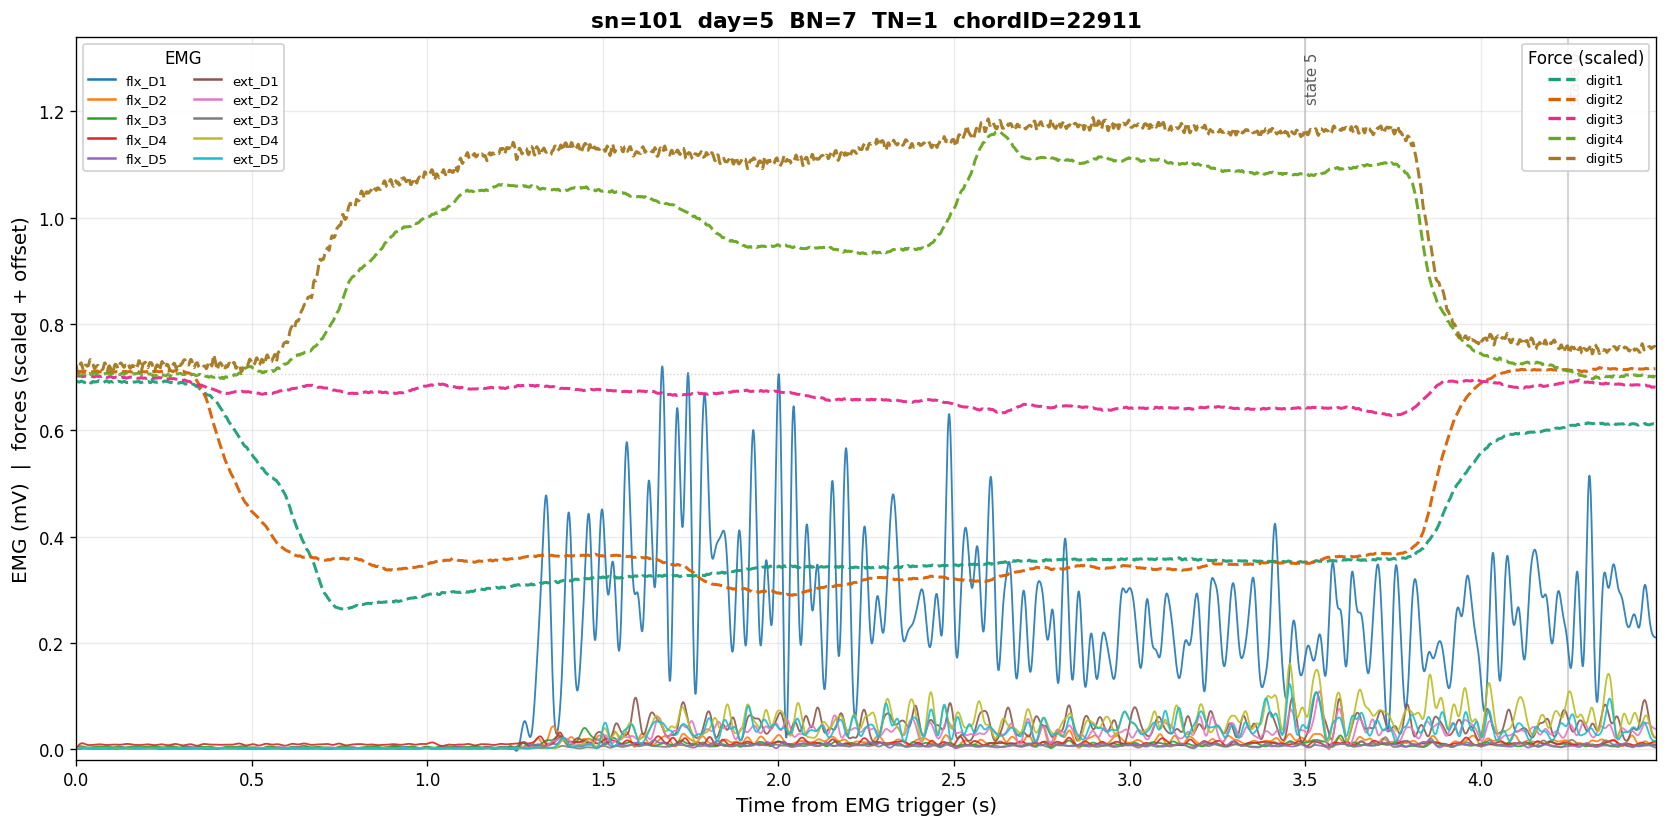

Force visual scale: raw peak≈3.61 → display amp≈0.47 (offset=0.705). EMG peak≈0.392.


In [5]:
# --- prepare signals on a shared time axis (EMG clock: t=0 at first state==4) ---
emg = np.asarray(row_emg['emg'], dtype=float)          # (N_emg, C_emg)
emg_channels = list(row_emg['channels'])
trial_state_emg = np.asarray(row_emg['trial_state'])
t_emg = np.arange(emg.shape[0], dtype=float) / fs_emg

forces = np.asarray(row_behav['forces'], dtype=float)  # (N_f, 5)
force_channels = list(row_behav['channels'])
state_behav = np.asarray(row_behav['trial_state'])
trial_time = np.asarray(row_behav['trial_time'], dtype=float)

hits = np.where(state_behav == EMG_TRIGGER_STATE)[0]
if len(hits) == 0:
    raise ValueError(f'No state=={EMG_TRIGGER_STATE} in behaviour trial; cannot align forces.')
t0 = trial_time[hits[0]]
t_force = trial_time - t0  # same origin as EMG

# keep forces that overlap the EMG window (plus a tiny pad for edges)
mask_f = (t_force >= -0.01) & (t_force <= t_emg[-1] + 0.01)
t_force_plot = t_force[mask_f]
forces_plot = forces[mask_f]

# --- scale / shift forces so they sit clearly above EMG ---
emg_peak = np.nanpercentile(np.abs(emg), 99)
if emg_peak <= 0:
    emg_peak = 1.0
force_peak = np.nanpercentile(np.abs(forces_plot), 99)
if force_peak <= 0:
    force_peak = 1.0

force_display_amp = emg_peak * 1.2          # target visual amplitude for forces
force_offset = emg_peak * 1.8               # lift forces above EMG
forces_scaled = forces_plot / force_peak * force_display_amp + force_offset

# --- colours ---
emg_cmap = plt.cm.tab10(np.linspace(0, 1, len(emg_channels), endpoint=False))
force_cmap = plt.cm.Dark2(np.linspace(0, 1, len(force_channels), endpoint=False))

fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

# EMG
for i, ch in enumerate(emg_channels):
    ax.plot(t_emg, emg[:, i], color=emg_cmap[i], lw=1.1, alpha=0.9, label=ch)

# Forces (dashed, thicker, shifted)
for i, ch in enumerate(force_channels):
    ax.plot(
        t_force_plot, forces_scaled[:, i],
        color=force_cmap[i], lw=1.8, ls='--', alpha=0.95, label=ch,
    )

# Faint vertical lines + labels at state transitions (EMG-aligned)
chg = np.where(np.diff(trial_state_emg) != 0)[0] + 1
for idx in chg:
    ax.axvline(t_emg[idx], color='0.55', lw=1.0, alpha=0.45, zorder=0)
    ax.text(
        t_emg[idx], 0.98, f'state {int(trial_state_emg[idx])}',
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=9, color='0.35',
        rotation=90,
    )

# reference line at force offset
ax.axhline(force_offset, color='0.7', lw=0.8, ls=':', alpha=0.6)

ax.set_xlim(0, t_emg[-1])
ymin = min(-0.05 * emg_peak, float(np.nanmin(emg)) * 1.05)
ymax = force_offset + force_display_amp * 1.35
ax.set_ylim(ymin, ymax)

ax.set_xlabel('Time from EMG trigger (s)', fontsize=12)
ax.set_ylabel('EMG (mV)  |  forces (scaled + offset)', fontsize=12)
ax.set_title(
    f'sn={sn}  day={day}  BN={BN}  TN={TN}  chordID={chordID}',
    fontsize=13, fontweight='bold',
)
ax.grid(True, alpha=0.25)

# Split legend: EMG left, forces right
emg_handles = [
    Line2D([0], [0], color=emg_cmap[i], lw=1.5, label=ch)
    for i, ch in enumerate(emg_channels)
]
force_handles = [
    Line2D([0], [0], color=force_cmap[i], lw=2.0, ls='--', label=ch)
    for i, ch in enumerate(force_channels)
]
leg1 = ax.legend(
    handles=emg_handles, title='EMG', loc='upper left',
    fontsize=8, framealpha=0.9, ncol=2,
)
ax.add_artist(leg1)
ax.legend(
    handles=force_handles, title='Force (scaled)', loc='upper right',
    fontsize=8, framealpha=0.9,
)

plt.tight_layout()
plt.show()

print(
    f'Force visual scale: raw peak≈{force_peak:.3g} → display amp≈{force_display_amp:.3g} '
    f'(offset={force_offset:.3g}). EMG peak≈{emg_peak:.3g}.'
)